In [1]:
import re
import json
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib import pyplot as plt
from typing import List, Dict, Any, Literal

BENCHMARK_FILE_MODE: Literal["all", "latest"] = "all"
""" Whether load and merge all benchmark files or use only latest one """

def list_benchmark_files() -> List[Path]:
    """ List all benchmark files sorted by datetime (desc) """

    benchmarks_dirs = list(Path('.').glob('**/.benchmarks'))
    json_files = []
    for bench_dir in benchmarks_dirs:
        json_files.extend(bench_dir.glob('**/*.json'))

    json_files.sort(key=lambda x: x.stat().st_mtime, reverse=True)

    if not json_files:
        raise ValueError("No benchmark data loaded!")
    
    return json_files

def load_benchmark_file(file: Path) -> pd.DataFrame:
    """ Load single benchmark file and extract the data into DataFrame"""
    content = json.loads(file.read_text())
    return extract_benchmark_data(content) \
        .assign(
            run_id=int(file.name.split("_")[0]),
            mtime=pd.Timestamp.fromtimestamp(file.stat().st_mtime)
        )

def extract_benchmark_data(benchmark_data: Dict[str, Any]) -> pd.DataFrame:
    """ Extract benchmark data into DataFrame """
    benchmarks = benchmark_data.get('benchmarks', [])

    # Extract data for each benchmark entry
    records = []
    for bench in benchmarks:

        # Parse test name
        # Options:
        #   "test_pyai_agent_perf[deepseek-chat-sql-1]"
        #   "test_lng_sql_agent_perf[gpt-oss:20b-1]"
        #   "test_bsl_agent_perf[qwen3:30b-1]" (older one, always lng)
        if not (m := re.search(r"\[.+\]", bench["name"])):
            raise ValueError(f"Cannot parse test name {bench['name']}: model part is missing")
        model_parts = m.group(0).strip("[]").split("-")

        query_number = int(model_parts[-1])
        agent_type = model_parts[-2] if model_parts[-2] in ("sql", "bsl") else None
        model_name = "-".join(model_parts[0:-2]) if agent_type else "-".join(model_parts[0:-1])

        agent_parts = re.sub(r"\[.+\]", "", bench["name"]).split("_")[1:-1]
        if agent_parts[0] not in ("lng", "pyai"):
            agent_parts = ["lng"] + agent_parts
        if agent_type:
            agent_parts = [agent_parts[0]] + [agent_type] + agent_parts[1:]

        agent = "_".join(agent_parts)

        # Get execution times and run statuses
        execution_times = bench.get('stats', {}).get('data', [])
        run_statuses = bench.get('extra_info', {}).get('run_status', [])
        
        # Each benchmark entry has multiple runs
        for i, exec_time in enumerate(execution_times):
            status = run_statuses[i] if i < len(run_statuses) else "UNKNOWN"
            records.append({
                'agent': agent,
                'model': model_name,
                'query_number': query_number,
                'execution_time': exec_time,
                'status': status,
                'is_success': not status.startswith("ERROR"),
            })

    # Create DataFrame
    return pd.DataFrame(records)

def load_and_merge_benchmark_files(files: List[Path]) -> pd.DataFrame:
    """ Load multiple benchmark files and merge them to a frame """
    df = pd.concat([load_benchmark_file(f) for f in files], axis=0, ignore_index=True)

    df["index"] = df \
        .groupby(["agent", "model", "query_number", "run_id"]) \
        ["execution_time"] \
        .transform(lambda x: np.arange(len(x)))

    df = df \
        .sort_values(["agent", "model", "query_number", "index", "run_id"]) \
        .drop_duplicates(["agent", "model", "query_number", "index"], keep="last") \
        .drop(columns=["index"]) \
        .query("model != 'deepseek-reasoner'") \
        .reset_index(drop=True)
    
    return df

In [2]:
files = list_benchmark_files()

match BENCHMARK_FILE_MODE:
    case "latest":
        df = load_benchmark_file(files[0])
    case "all":
        df = load_and_merge_benchmark_files(files)

df.sample(min(len(df), 10))

,agent,model,query_number,execution_time,status,is_success,run_id,mtime
363,pyai_bsl_agent,deepseek-chat,1,17.967663,PASSED,True,16,2026-03-11 10:45:28.452629
478,pyai_bsl_agent,gpt-oss:20b,1,7.345212,PASSED,True,17,2026-03-11 10:52:16.407278
880,pyai_sql_agent,qwen3:30b,3,12.529001,"ERROR: status_code: 400, model_name: qwen3:30b...",False,13,2026-03-09 20:27:09.951451
417,pyai_bsl_agent,deepseek-chat,2,22.505445,PASSED,True,15,2026-03-11 10:33:06.562019
708,pyai_sql_agent,deepseek-chat,3,27.820372,PASSED,True,13,2026-03-09 20:27:09.951451
325,lng_sql_agent,qwen3:30b,1,37.969843,PASSED,True,3,2026-03-05 10:48:59.767240
662,pyai_sql_agent,deepseek-chat,2,37.414215,PASSED,True,13,2026-03-09 20:27:09.951451
303,lng_sql_agent,qwen3:30b,1,39.882881,PASSED,True,3,2026-03-05 10:48:59.767240
353,lng_sql_agent,qwen3:30b,2,68.570024,PASSED,True,3,2026-03-05 10:48:59.767240
79,lng_bsl_agent,gpt-oss:20b,1,9.667959,PASSED,True,8,2026-03-05 16:46:48.868465


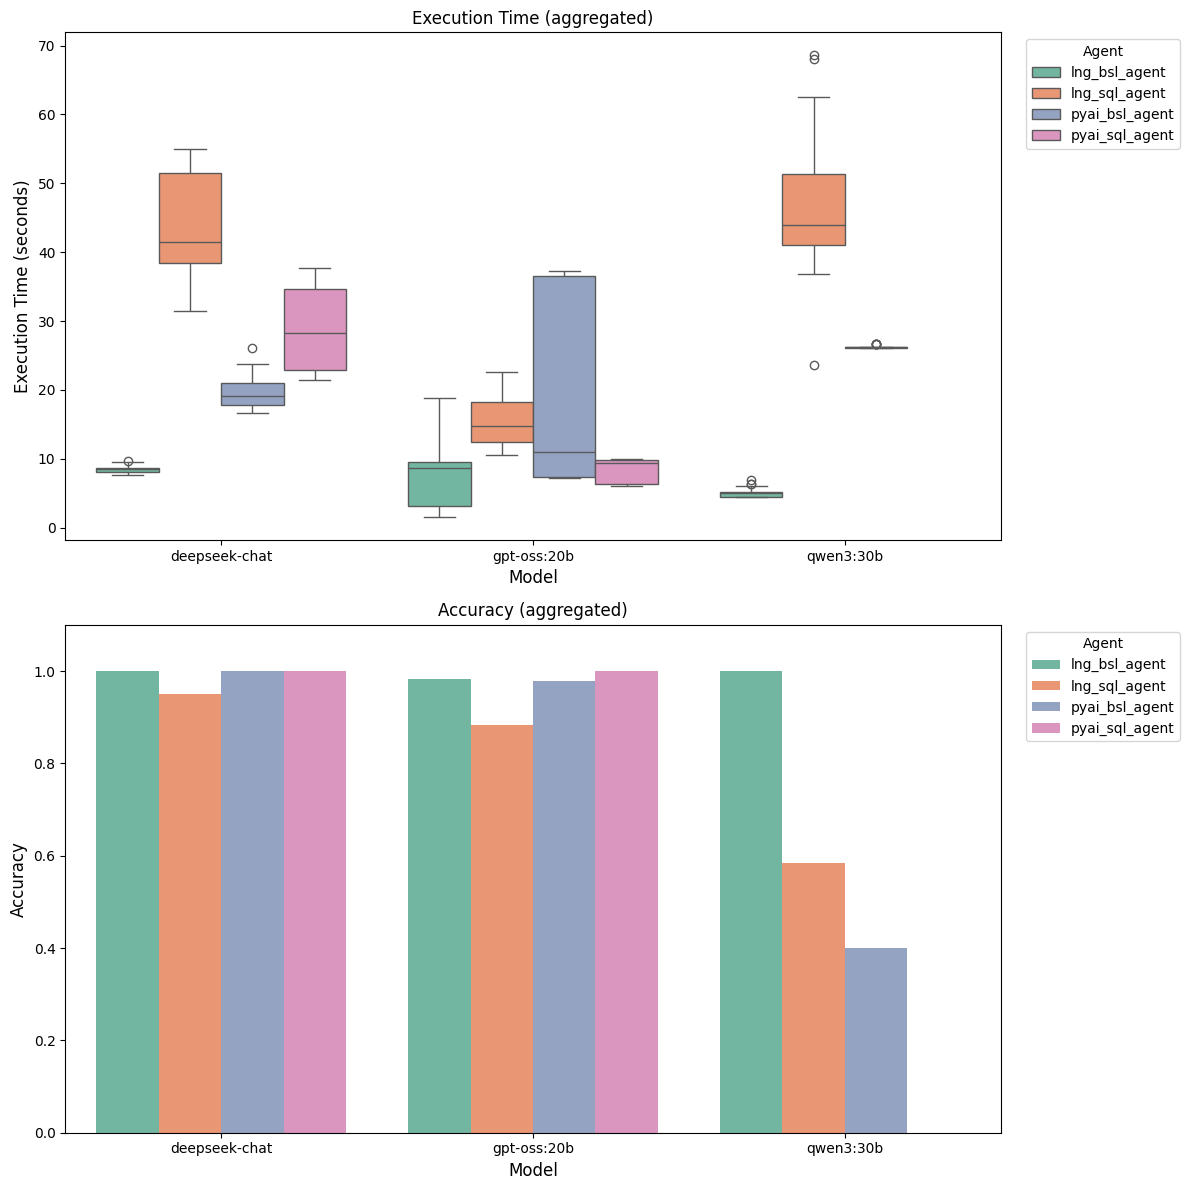

In [3]:
# Calculate statistics aggregated by agent and model

def filter_outliers_by_iqr(data: pd.DataFrame, grouping: str | List[str] = ['agent', 'model'], threshold: float= 1.5) -> pd.DataFrame:
    iqr = data \
        .groupby(grouping, as_index=False) \
        .agg(
            q1=pd.NamedAgg('execution_time',aggfunc=lambda x: x.quantile(0.25)),
            q3=pd.NamedAgg('execution_time',aggfunc=lambda x: x.quantile(0.75)),
        ) \
        .assign(
            iqr=lambda df: df["q3"] - df["q1"],
            lower=lambda df: df["q1"] - threshold * df["iqr"],
            upper=lambda df: df["q3"] + threshold * df["iqr"],
        )
    
    filtered = pd.merge(data, iqr, on=grouping) \
                .assign(is_outlier=lambda df: (df["execution_time"] < df["lower"]) | (df["execution_time"] > df["upper"])) \
                .query("~is_outlier") \
                .drop(columns=["q1", "q3", "iqr", "lower", "upper", "is_outlier"])
    
    return filtered

def filter_outliers_by_mad(data: pd.DataFrame, grouping: str | List[str] = ['agent', 'model'], threshold: float = 3.5) -> pd.DataFrame:
    med = data \
        .groupby(grouping, as_index=False) \
        .agg(
            med=pd.NamedAgg('execution_time','median'),
        )
    ad = pd.merge(data, med, on=grouping) \
        .assign(
            ad=lambda df: np.abs(df['execution_time'] - df['med'])
        )
    mad = ad \
        .groupby(grouping, as_index=False) \
        .agg(
            mad=pd.NamedAgg('ad','median'),
        )

    zscore = pd.merge(ad, mad, on=grouping) \
        .assign(
            zscore=lambda df: 0.6745 * (df['execution_time'] - df['med']) / (df['mad'] + 10.0),
            is_outlier=lambda df: df['zscore'].abs() > threshold,
        )

    filtered = zscore.query("~is_outlier") \
        .drop(columns=["med", "ad", "mad", "zscore", "is_outlier"])
    
    return filtered

df_success = df[df["is_success"]]
df_filtered = filter_outliers_by_iqr(df_success)

df_stats = df_filtered \
    .groupby(['agent', 'model'], as_index=False) \
    .agg(
        min_time=pd.NamedAgg('execution_time','min'),
        max_time=pd.NamedAgg('execution_time','max'),
        median_time=pd.NamedAgg('execution_time','median'),
    )

df_accuracy = df \
    .groupby(['agent', 'model'], as_index=False) \
    .agg(
        total_runs=pd.NamedAgg('status','count'),
        success_runs=pd.NamedAgg('is_success', 'sum'),
    ) \
    .assign(accuracy = lambda df: df['success_runs'] / df['total_runs']) \
    .drop(columns=["total_runs", "success_runs"])

stats_table = pd.merge(df_stats, df_accuracy, on=["agent", "model"])

display(
    stats_table.pivot(index=["agent"], columns="model") \
    .style \
    .format("{:.2f}") \
    .set_caption("Benchmark statistics (aggregated)") \
    .set_table_styles([
        {'selector': 'caption', 'props': [('text-align', 'center')]},
        {'selector': 'th', 'props': [('text-align', 'center')]}
    ])
)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

ax1 = axes[0]
boxes = sns.boxplot(data=df_filtered, x='model', y='execution_time', hue="agent", ax=ax1, palette='Set2')

ax1.set_title('Execution Time (aggregated)', fontsize=12)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
ax1.legend(title='Agent', bbox_to_anchor=(1.02, 1), loc='upper left')

# sns.stripplot(data=df_filtered, x='model', y='execution_time', hue='agent', ax=ax1, alpha=0.3, size=3, dodge=False, legend=False)

ax2 = axes[1]
accuracy_sorted = stats_table.sort_values(['model', 'agent'], ascending=True)

bars = sns.barplot(data=accuracy_sorted, x='model', y='accuracy', hue='agent', ax=ax2, palette='Set2')

ax2.set_title('Accuracy (aggregated)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.legend(title='Agent', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [4]:
# df_filtered.query("(model=='deepseek-chat') & (agent=='pyai_bsl_agent')")

In [5]:
# Calculate statistics by agent, model and query

df_filtered = filter_outliers_by_iqr(df_success, ['agent', 'model', 'query_number'])

df_stats = df_filtered \
    .groupby(['agent', 'model', 'query_number'], as_index=False) \
    .agg(
        min_time=pd.NamedAgg('execution_time','min'),
        max_time=pd.NamedAgg('execution_time','max'),
        median_time=pd.NamedAgg('execution_time','median'),
    )

df_accuracy = df \
    .groupby(['agent', 'model', 'query_number'], as_index=False) \
    .agg(
        total_runs=pd.NamedAgg('status','count'),
        success_runs=pd.NamedAgg('is_success', 'sum'),
    ) \
    .assign(accuracy = lambda df: df['success_runs'] / df['total_runs']) \
    .drop(columns=["total_runs", "success_runs"])

stats_table = pd.merge(df_stats, df_accuracy, on=["agent", "model", "query_number"])

display(
    stats_table.pivot(index=["agent", "query_number"], columns=["model"]) \
    .style \
    .format("{:.2f}") \
    .set_caption("Benchmark statistics (per query_number)") \
    .set_table_styles([
        {'selector': 'caption', 'props': [('text-align', 'center')]},
        {'selector': 'th', 'props': [('text-align', 'center')]}
    ])
)